### **Homework: Regularization in Machine Learning**

#### Objective:
The objective of this homework is to understand the concept of **regularization** in machine learning by applying **Ridge Regression** and **Lasso Regression** to a real-world dataset. You will explore how regularization techniques can reduce overfitting and improve the generalization of models.

#### Dataset:
Use the **California Housing Dataset**: `data/california_housing.csv`. The dataset contains housing data for various neighborhoods in California.

#### Dataset Overview:
Key features:
- **MedInc**: Median income in the neighborhood.
- **HouseAge**: Median age of the houses in the neighborhood.
- **AveRooms**: Average number of rooms per household.
- **AveBedrms**: Average number of bedrooms per household.
- **Population**: Total population in the neighborhood.
- **AveOccup**: Average number of people per household.
- **Latitude**: Latitude of the neighborhood.
- **Longitude**: Longitude of the neighborhood.

Target variable:
- **MedHouseVal**: Median house value for the neighborhood (in $100,000s).


#### Steps to Complete:

1. **Load the Dataset**
   - Load the California Housing dataset.
   - Convert the dataset into a pandas DataFrame for easier handling.

2. **Data Exploration**
   - Display the first few rows of the dataset.
   - Check for missing values and handle them if necessary.
   - Explore feature correlations with the target variable (`MedHouseVal`) using a heatmap or scatter plots.

3. **Data Preprocessing**
   - Split the data into training and test sets (80% train, 20% test) using `train_test_split`.
   - Standardize the features using `StandardScaler` to ensure all features are on the same scale.

4. **Baseline Model**
   - Fit a simple **Linear Regression** model to the training data.
   - Evaluate its performance on the test set using:
     - **Mean Squared Error (MSE)**
     - **R-squared (R²)**

5. **Ridge Regression**
   - Apply **Ridge Regression** with different values of the regularization parameter (`alpha`).
   - Use cross-validation to find the optimal `alpha`.
   - Plot the model coefficients as a function of `alpha`.
   - Evaluate the Ridge Regression model and compare it to the baseline model.

6. **Lasso Regression**
   - Apply **Lasso Regression** with different values of `alpha`.
   - Use cross-validation to find the optimal `alpha`.
   - Plot the model coefficients as a function of `alpha`.
   - Evaluate the Lasso Regression model and compare it to the baseline and Ridge models.

7. **Model Comparison**
   - Compare the performance of Linear Regression, Ridge Regression, and Lasso Regression in terms of:
     - MSE
     - R²
     - Number of non-zero coefficients in each model (for Lasso).

8. **Insights**
   - Discuss the impact of regularization on model performance and feature selection.
   - Reflect on how Ridge and Lasso handle overfitting differently.
   - Identify the most important features for predicting house prices based on the Lasso model.

#### Bonus Challenges (Optional):

1. **ElasticNet Regularization**
   - Apply **ElasticNet**, which combines Ridge and Lasso regularization, and tune the `l1_ratio` parameter.
   - Compare its performance with Ridge and Lasso.

2. **Real-World Dataset**
   - Use a different dataset (e.g., a Kaggle dataset) and repeat the analysis to gain more experience.

#### Deliverables:
- A Python script or Jupyter Notebook containing:
  - Data exploration, preprocessing, and model implementation.
  - Visualizations of model coefficients and performance metrics.
  - Comparison of models and discussion of results.
- A brief report discussing:
  - The impact of regularization on model performance.
  - How Ridge and Lasso handle overfitting.
  - Insights into feature importance and model interpretability.

#### Useful Hints:
- Use `GridSearchCV` or `cross_val_score` to tune hyperparameters.
- Regularization parameters (`alpha`) should be explored over a range of values (e.g., logarithmic scale).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, Ridge, LassoCV, Lasso, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

csv_path = "data/california_housing.csv"
df = pd.read_csv(csv_path)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

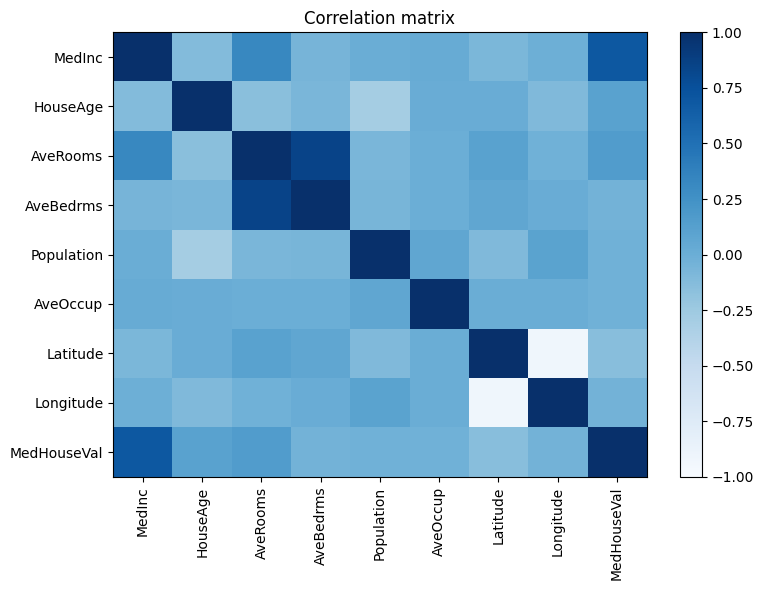

In [6]:
# Correlations with target
corr = df.corr()
display(corr["MedHouseVal"].sort_values(ascending=False))

# Correlation matrix image (one plot)
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto', cmap='Blues', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


In [7]:
target = "MedHouseVal"
feature_names = list(df.drop(columns=[target]).columns)

X = df.drop(columns=[target]).values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train shape:", X_train_s.shape, "Test shape:", X_test_s.shape)


Train shape: (16512, 8) Test shape: (4128, 8)


Linear Regression
Test MSE: 0.5558915986952444
Test R2: 0.5757877060324508


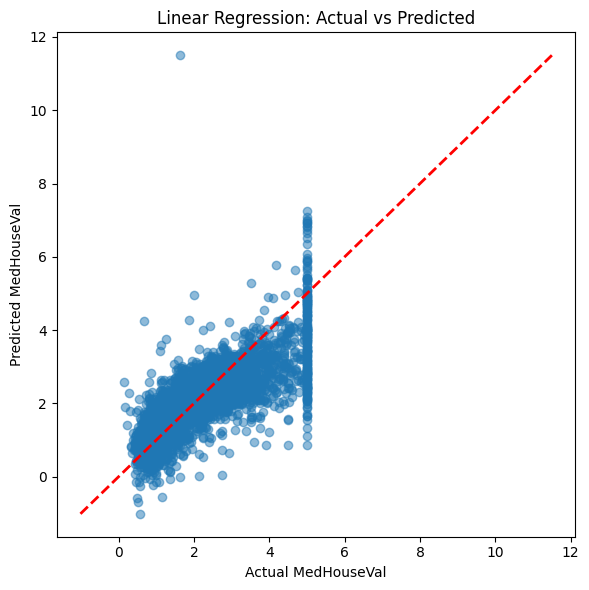

In [9]:
lin = LinearRegression().fit(X_train_s, y_train)
y_pred_lin = lin.predict(X_test_s)
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression")
print("Test MSE:", mse_lin)
print("Test R2:", r2_lin)

mn = min(y_test.min(), y_pred_lin.min())
mx = max(y_test.max(), y_pred_lin.max())

# scatter plot (separate)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lin, alpha=0.5)
plt.plot([mn,mx],[mn,mx], linestyle='--', linewidth=2, color='red')
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

Ridge
Best alpha: 0.001
Test MSE: 0.5558915618350113
Test R2: 0.5757877341612515


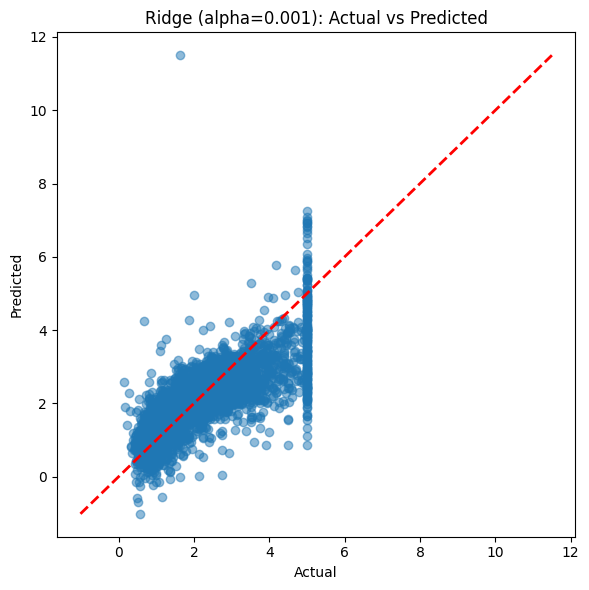

In [10]:
alphas_ridge = np.logspace(-3, 3, 50)
ridgecv = RidgeCV(alphas=alphas_ridge, cv=5).fit(X_train_s, y_train)
best_alpha_ridge = ridgecv.alpha_
ridge_best = Ridge(alpha=best_alpha_ridge).fit(X_train_s, y_train)
y_pred_ridge = ridge_best.predict(X_test_s)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge")
print("Best alpha:", best_alpha_ridge)
print("Test MSE:", mse_ridge)
print("Test R2:", r2_ridge)

mn = min(y_test.min(), y_pred_ridge.min())
mx = max(y_test.max(), y_pred_ridge.max())

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5)
plt.plot([mn,mx],[mn,mx], linestyle='--', linewidth=2, color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Ridge (alpha={best_alpha_ridge:.4g}): Actual vs Predicted")
plt.tight_layout()
plt.show()


Lasso
Best alpha: 0.0006551285568595509
Test MSE: 0.5549581025845478
Test R2: 0.5765000760834784
Non-zero coefs: 8


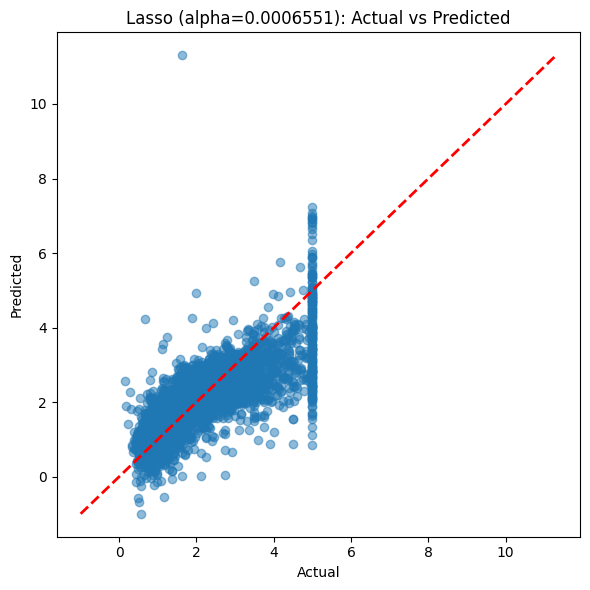

In [11]:
lassocv = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, max_iter=10000, random_state=42).fit(X_train_s, y_train)
best_alpha_lasso = lassocv.alpha_
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000).fit(X_train_s, y_train)
y_pred_lasso = lasso_best.predict(X_test_s)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
n_nonzero_lasso = np.sum(np.abs(lasso_best.coef_) > 1e-8)

print("Lasso")
print("Best alpha:", best_alpha_lasso)
print("Test MSE:", mse_lasso)
print("Test R2:", r2_lasso)
print("Non-zero coefs:", n_nonzero_lasso)

mn = min(y_test.min(), y_pred_lasso.min())
mx = max(y_test.max(), y_pred_lasso.max())

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lasso, alpha=0.5)

plt.plot([mn,mx],[mn,mx], linestyle='--', linewidth=2, color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Lasso (alpha={best_alpha_lasso:.4g}): Actual vs Predicted")
plt.tight_layout()
plt.show()


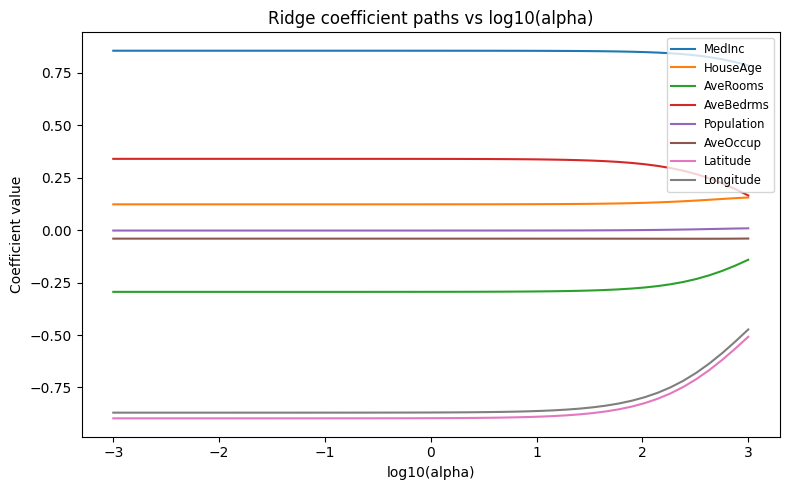

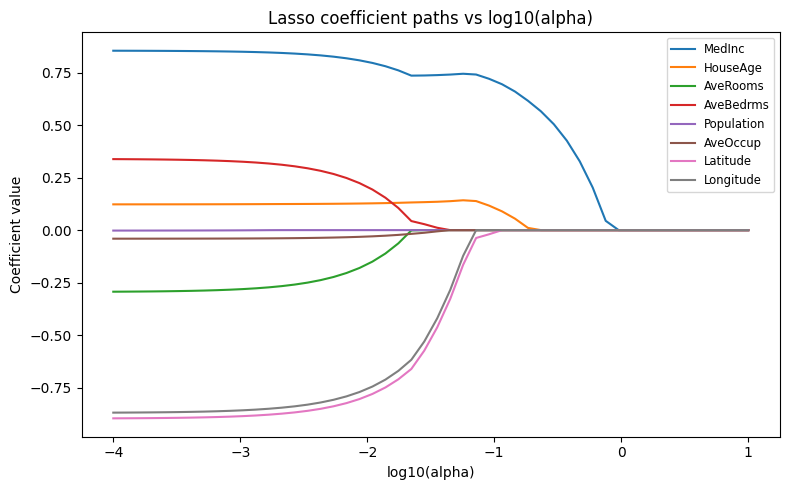

In [ ]:
alphas_path = np.logspace(-3, 3, 50)
coefs_ridge = []
for a in alphas_path:
    r = Ridge(alpha=a).fit(X_train_s, y_train)
    coefs_ridge.append(r.coef_)
coefs_ridge = np.array(coefs_ridge)

plt.figure(figsize=(8,5))
for i in range(coefs_ridge.shape[1]):
    plt.plot(np.log10(alphas_path), coefs_ridge[:, i], label=feature_names[i])
plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("Ridge coefficient paths vs log10(alpha)")
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

# Lasso path
alphas_path_lasso = np.logspace(-4, 1, 50)
coefs_lasso = []
for a in alphas_path_lasso:
    l = Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train)
    coefs_lasso.append(l.coef_)
coefs_lasso = np.array(coefs_lasso)

plt.figure(figsize=(8,5))
for i in range(coefs_lasso.shape[1]):
    plt.plot(np.log10(alphas_path_lasso), coefs_lasso[:, i], label=feature_names[i])
plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("Lasso coefficient paths vs log10(alpha)")
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

ElasticNet
Best alpha: 0.0007278953843983154 Best l1_ratio: 1.0
Test MSE: 0.5548583011365528
Test R2: 0.5765762366178248
Non-zero coefs: 8


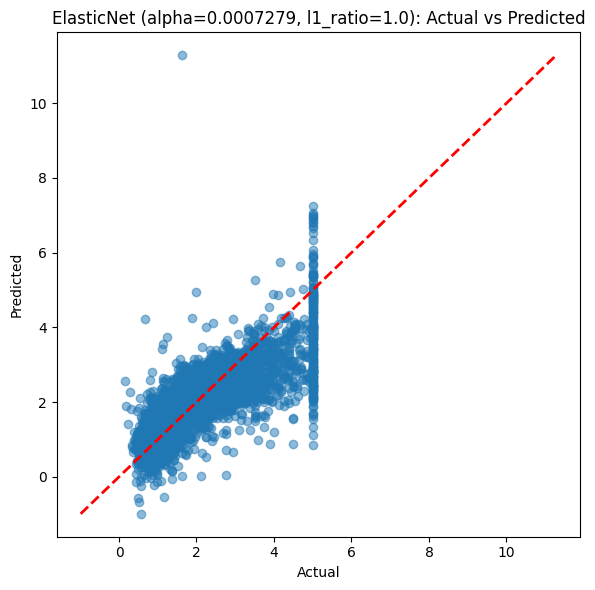

In [13]:
en_cv = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1.0],
                     alphas=np.logspace(-4, 1, 30), cv=5, max_iter=10000, random_state=42).fit(X_train_s, y_train)
best_alpha_en = en_cv.alpha_
best_l1_ratio = en_cv.l1_ratio_
y_pred_en = en_cv.predict(X_test_s)
mse_en = mean_squared_error(y_test, y_pred_en)
r2_en = r2_score(y_test, y_pred_en)
n_nonzero_en = np.sum(np.abs(en_cv.coef_) > 1e-8)

print("ElasticNet")
print("Best alpha:", best_alpha_en, "Best l1_ratio:", best_l1_ratio)
print("Test MSE:", mse_en)
print("Test R2:", r2_en)
print("Non-zero coefs:", n_nonzero_en)

mn = min(y_test.min(), y_pred_en.min())
mx = max(y_test.max(), y_pred_en.max())

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_en, alpha=0.5)
plt.plot([mn,mx],[mn,mx], linestyle='--', linewidth=2, color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"ElasticNet (alpha={best_alpha_en:.4g}, l1_ratio={best_l1_ratio}): Actual vs Predicted")
plt.tight_layout()
plt.show()


In [ ]:
results = [
    ("LinearRegression", mean_squared_error(y_test, y_pred_lin), r2_score(y_test, y_pred_lin), None, np.sum(np.abs(lin.coef_)>1e-8)),
    ("Ridge", mean_squared_error(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge), best_alpha_ridge, np.sum(np.abs(ridge_best.coef_)>1e-8)),
    ("Lasso", mean_squared_error(y_test, y_pred_lasso), r2_score(y_test, y_pred_lasso), best_alpha_lasso, n_nonzero_lasso),
    ("ElasticNet", mean_squared_error(y_test, y_pred_en), r2_score(y_test, y_pred_en), best_alpha_en, n_nonzero_en)
]
results_df = pd.DataFrame(results, columns=["Model", "Test MSE", "Test R2", "Alpha", "Non-zero Coefs"])
display(results_df.round(4))

coef_table = pd.DataFrame({
    "feature": feature_names,
    "Linear_coef": lin.coef_,
    "Ridge_coef": ridge_best.coef_,
    "Lasso_coef": lasso_best.coef_,
    "ElasticNet_coef": en_cv.coef_
}).set_index("feature")
display(coef_table.round(4))

# To identify most important features (Lasso): sort by absolute coefficient
important = coef_table["Lasso_coef"].abs().sort_values(ascending=False)
print("Lasso: features sorted by absolute coefficient (desc):")
display(important)


,Model,Test MSE,Test R2,Alpha,Non-zero Coefs
0,LinearRegression,0.5559,0.5758,NaN,8
1,Ridge,0.5559,0.5758,0.0010,8
2,Lasso,0.5550,0.5765,0.0007,8
3,ElasticNet,0.5549,0.5766,0.0007,8


,Linear_coef,Ridge_coef,Lasso_coef,ElasticNet_coef
feature,,,,
MedInc,0.8544,0.8544,0.8510,0.8506
HouseAge,0.1225,0.1225,0.1231,0.1231
AveRooms,-0.2944,-0.2944,-0.2858,-0.2849
AveBedrms,0.3393,0.3393,0.3306,0.3297
Population,-0.0023,-0.0023,-0.0015,-0.0014
AveOccup,-0.0408,-0.0408,-0.0402,-0.0401
Latitude,-0.8969,-0.8969,-0.8896,-0.8888
Longitude,-0.8698,-0.8698,-0.8621,-0.8613


Lasso: features sorted by absolute coefficient (desc):


feature
Latitude      0.889634
Longitude     0.862129
MedInc        0.850956
AveBedrms     0.330616
AveRooms      0.285817
HouseAge      0.123072
AveOccup      0.040214
Population    0.001491
Name: Lasso_coef, dtype: float64